# 04 — PySpark Preprocessing
**Projet** : PFE Scoring Crédit Bancaire  
**Dataset** : `marts_marts.dataset_ml_v3` — 8 570 101 lignes | 105 colonnes  
**Objectif** : Préparer le dataset pour l'entraînement des modèles ML

---
### Pipeline
1. Configuration PySpark + Connexion PostgreSQL
2. Chargement du dataset
3. Split Temporel (Train / Validation / Test / Scoring)
4. Exploration et Analyse des NULLs
5. Imputation des valeurs manquantes
6. Encodage des variables catégorielles
7. Analyse de redondance entre colonnes

---
## ETAPE 1 — Configuration PySpark + Connexion PostgreSQL

In [ ]:
import os
os.environ['JAVA_HOME']             = r'C:\Program Files\Eclipse Adoptium\jdk-17.0.17.10-hotspot'
os.environ['HADOOP_HOME']           = r'C:\hadoop'
os.environ['SPARK_HOME']            = r'C:\Users\saadb\credit_scoring_env\Lib\site-packages\pyspark'
os.environ['PYSPARK_PYTHON']        = r'C:\Users\saadb\credit_scoring_env\Scripts\python.exe'
os.environ['PYSPARK_DRIVER_PYTHON'] = r'C:\Users\saadb\credit_scoring_env\Scripts\python.exe'
os.environ['PATH'] = os.environ['JAVA_HOME'] + r'\bin;' + os.environ['HADOOP_HOME'] + r'\bin;' + os.environ['PATH']

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, isnull, count, round as spark_round
from pyspark.sql.functions import percentile_approx
from pyspark.sql.functions import isnull, sum as spark_sum, count
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline


JAR_PATH = "file:///C:/Users/saadb/pfe-scoring-credit/jars/postgresql-42.7.10.jar"

spark = SparkSession.builder \
    .appName("PFE_CreditScoring") \
    .config("spark.driver.memory", "6g") \
    .config("spark.driver.maxResultSize", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.jars", JAR_PATH) \
    .master("local[2]") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print(f" Spark version : {spark.version}")

---
## ETAPE 2 — Chargement du Dataset

In [15]:
JDBC_URL   = "jdbc:postgresql://localhost:5433/pfe_credit_dw"
JDBC_PROPS = {"user": "postgres", "password": "Saad2002", 
              "driver": "org.postgresql.Driver"}

df = spark.read.jdbc(url=JDBC_URL, table="marts_marts.dataset_ml_v3", 
                     properties=JDBC_PROPS)
print(f" Dataset : {df.count():,} lignes | {len(df.columns)} colonnes")

 Dataset : 8,570,101 lignes | 105 colonnes


---
## ETAPE 3 — Split Temporel

Validation temporelle — on respecte la chronologie pour eviter le data leakage :
- **Train** : 012025 a 102025 (10 mois)
- **Validation** : 112025 (1 mois) — tuning hyperparametres
- **Test** : 122025 (1 mois) — evaluation finale honnete
- **Scoring** : 012026 — prediction reelle

> Note : Decembre presente une saisonnalite (fetes) avec flag=1 = 0.038% vs 0.052% en moyenne. Ce phenomene est documente et fait partie de la realite bancaire.

In [ ]:



TRAIN_PERIODS = ['012025','022025','032025','042025','052025',
                 '062025','072025','082025','092025','102025']
VAL_PERIOD    = ['112025']
TEST_PERIOD   = ['122025']
SCORE_PERIOD  = ['012026']


df_train_full = df.filter(col('is_prediction_period') == 0)
df_score      = df.filter(col('is_prediction_period') == 1)


df_train = df_train_full.filter(col('periode_trt').isin(TRAIN_PERIODS))
df_val   = df_train_full.filter(col('periode_trt').isin(VAL_PERIOD))
df_test  = df_train_full.filter(col('periode_trt').isin(TEST_PERIOD))

print(f" Train      : {df_train.count():>10,} lignes | flag=1 : {df_train.filter(col('flag_transfo')==1).count():,}")
print(f" Validation : {df_val.count():>10,} lignes | flag=1 : {df_val.filter(col('flag_transfo')==1).count():,}")
print(f" Test       : {df_test.count():>10,} lignes | flag=1 : {df_test.filter(col('flag_transfo')==1).count():,}")
print(f" Scoring    : {df_score.count():>10,} lignes (012026 à prédire)")

 Train      :  6,524,541 lignes | flag=1 : 3,411
 Validation :    675,418 lignes | flag=1 : 399
 Test       :    681,699 lignes | flag=1 : 260
 Scoring    :    688,443 lignes (012026 à prédire)


In [17]:
df.printSchema()

root
 |-- tiers_client: string (nullable = true)
 |-- periode_trt: string (nullable = true)
 |-- is_prediction_period: integer (nullable = true)
 |-- flag_transfo: integer (nullable = true)
 |-- date_trt_extr_global: timestamp (nullable = true)
 |-- age: decimal(38,18) (nullable = true)
 |-- revenu: decimal(38,18) (nullable = true)
 |-- nbr_enfant: decimal(38,18) (nullable = true)
 |-- charges: decimal(38,18) (nullable = true)
 |-- mensualite_loyer: decimal(38,18) (nullable = true)
 |-- flag_eligible_md: integer (nullable = true)
 |-- csp_mkt: string (nullable = true)
 |-- secteur_activite: string (nullable = true)
 |-- civilite_client: string (nullable = true)
 |-- prem_produit: string (nullable = true)
 |-- canal_ent_relation: string (nullable = true)
 |-- type_client: string (nullable = true)
 |-- activite_profession: string (nullable = true)
 |-- dernier_evt: string (nullable = true)
 |-- anciennete_annees: decimal(38,18) (nullable = true)
 |-- anciennete_emploi: decimal(38,18) (nu

---
## ETAPE 4 — Exploration et Analyse des NULLs



**Strategie d'imputation :**
- NULL logique (absence produit/service) → `0`
- NULL erreur saisie → mediane training
- NULL categoriel → `INCONNU`

In [ ]:
import psycopg2
import pandas as pd

conn = psycopg2.connect(
    host="localhost", port=5433, database="pfe_credit_dw",
    user="postgres", password="Saad2002"
)


query = """
SELECT
    col,
    ROUND(null_count * 100.0 / total, 2) AS pct_null
FROM (
    SELECT 'age' AS col, COUNT(*) FILTER (WHERE age IS NULL) AS null_count, COUNT(*) AS total FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'revenu', COUNT(*) FILTER (WHERE revenu IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'nbr_enfant', COUNT(*) FILTER (WHERE nbr_enfant IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'charges', COUNT(*) FILTER (WHERE charges IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'mensualite_loyer', COUNT(*) FILTER (WHERE mensualite_loyer IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'anciennete_annees', COUNT(*) FILTER (WHERE anciennete_annees IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'anciennete_emploi', COUNT(*) FILTER (WHERE anciennete_emploi IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'nb_jours_dernier_evt', COUNT(*) FILTER (WHERE nb_jours_dernier_evt IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'moy_taux_credit', COUNT(*) FILTER (WHERE moy_taux_credit IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'moy_mt_init_brut', COUNT(*) FILTER (WHERE moy_mt_init_brut IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'moy_mt_cap_rest', COUNT(*) FILTER (WHERE moy_mt_cap_rest IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'moy_duree_initiale', COUNT(*) FILTER (WHERE moy_duree_initiale IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'moy_retard_echeance', COUNT(*) FILTER (WHERE moy_retard_echeance IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'nb_credits', COUNT(*) FILTER (WHERE nb_credits IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'nb_sav', COUNT(*) FILTER (WHERE nb_sav IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'nb_campagnes', COUNT(*) FILTER (WHERE nb_campagnes IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'nb_reclamations', COUNT(*) FILTER (WHERE nb_reclamations IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'nb_demandes', COUNT(*) FILTER (WHERE nb_demandes IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'sav_moy_duree_traitement', COUNT(*) FILTER (WHERE sav_moy_duree_traitement IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'dem_moy_delai_extraction', COUNT(*) FILTER (WHERE dem_moy_delai_extraction IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
) t
ORDER BY pct_null DESC;
"""

df_null = pd.read_sql(query, conn)
conn.close()

print(df_null.to_string(index=False))

C:\Users\saadb\AppData\Local\Temp\ipykernel_14612\333550761.py:39: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_null = pd.read_sql(query, conn)


                     col  pct_null
         nb_reclamations     99.28
dem_moy_delai_extraction     97.47
             nb_demandes     97.47
        mensualite_loyer     88.70
    nb_jours_dernier_evt     79.52
sav_moy_duree_traitement     71.52
                  nb_sav     65.61
                 charges     64.91
            nb_campagnes     44.86
              nbr_enfant     44.85
       anciennete_emploi     23.59
                  revenu     19.10
                     age     11.78
       anciennete_annees      7.83
        moy_mt_init_brut      1.58
         moy_mt_cap_rest      1.58
     moy_retard_echeance      1.58
      moy_duree_initiale      1.58
              nb_credits      1.58
         moy_taux_credit      1.58


In [ ]:


query = """
SELECT col, ROUND(null_count * 100.0 / total, 2) AS pct_null
FROM (
    SELECT 'moy_montant_bien' AS col, COUNT(*) FILTER (WHERE moy_montant_bien IS NULL) AS null_count, COUNT(*) AS total FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'moy_mt_apport', COUNT(*) FILTER (WHERE moy_mt_apport IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'moy_mt_rachat_tot', COUNT(*) FILTER (WHERE moy_mt_rachat_tot IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'moy_mt_vr', COUNT(*) FILTER (WHERE moy_mt_vr IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'moy_mt_dg', COUNT(*) FILTER (WHERE moy_mt_dg IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'total_nb_impaye', COUNT(*) FILTER (WHERE total_nb_impaye IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'total_nb_impaye_regle', COUNT(*) FILTER (WHERE total_nb_impaye_regle IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'total_solde_impaye', COUNT(*) FILTER (WHERE total_solde_impaye IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'max_nb_impaye', COUNT(*) FILTER (WHERE max_nb_impaye IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'moy_taux_credit', COUNT(*) FILTER (WHERE moy_taux_credit IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'moy_mensualite', COUNT(*) FILTER (WHERE moy_mensualite IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'moy_mensualite_av_der', COUNT(*) FILTER (WHERE moy_mensualite_av_der IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'moy_duree_initiale', COUNT(*) FILTER (WHERE moy_duree_initiale IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'moy_duree_actuelle', COUNT(*) FILTER (WHERE moy_duree_actuelle IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'moy_nbr_ech_rest', COUNT(*) FILTER (WHERE moy_nbr_ech_rest IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'moy_differe', COUNT(*) FILTER (WHERE moy_differe IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'flag_impaye', COUNT(*) FILTER (WHERE flag_impaye IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'flag_contentieux', COUNT(*) FILTER (WHERE flag_contentieux IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'flag_credit_auto', COUNT(*) FILTER (WHERE flag_credit_auto IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'flag_credit_equip', COUNT(*) FILTER (WHERE flag_credit_equip IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'flag_credit_perso', COUNT(*) FILTER (WHERE flag_credit_perso IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'flag_prel_prelevement', COUNT(*) FILTER (WHERE flag_prel_prelevement IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'nb_credits_ctx', COUNT(*) FILTER (WHERE nb_credits_ctx IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'moy_retard_echeance', COUNT(*) FILTER (WHERE moy_retard_echeance IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'aff_moy_delai_extraction', COUNT(*) FILTER (WHERE aff_moy_delai_extraction IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
) t
ORDER BY pct_null DESC;
"""

df_null2 = pd.read_sql(query, conn)
conn.close()
print(df_null2.to_string(index=False))

C:\Users\saadb\AppData\Local\Temp\ipykernel_14612\3007227961.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_null2 = pd.read_sql(query, conn)


                     col  pct_null
        moy_nbr_ech_rest      9.15
       moy_mt_rachat_tot      1.58
               moy_mt_dg      1.58
   total_nb_impaye_regle      1.58
           max_nb_impaye      1.58
          moy_mensualite      1.58
      moy_duree_initiale      1.58
           moy_mt_apport      1.58
             flag_impaye      1.58
aff_moy_delai_extraction      1.58
     moy_retard_echeance      1.58
          nb_credits_ctx      1.58
   flag_prel_prelevement      1.58
       flag_credit_perso      1.58
       flag_credit_equip      1.58
        flag_credit_auto      1.58
        flag_contentieux      1.58
        moy_montant_bien      1.58
               moy_mt_vr      1.58
         total_nb_impaye      1.58
      total_solde_impaye      1.58
         moy_taux_credit      1.58
   moy_mensualite_av_der      1.58
      moy_duree_actuelle      1.58
             moy_differe      1.58


In [ ]:


query = """
SELECT col, ROUND(null_count * 100.0 / total, 2) AS pct_null
FROM (
    SELECT 'canal_prov_principal' AS col, COUNT(*) FILTER (WHERE canal_prov_principal IS NULL) AS null_count, COUNT(*) AS total FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'code_reseau_principal', COUNT(*) FILTER (WHERE code_reseau_principal IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'type_bien_principal', COUNT(*) FILTER (WHERE type_bien_principal IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'nb_campagnes', COUNT(*) FILTER (WHERE nb_campagnes IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'nb_contacts_total', COUNT(*) FILTER (WHERE nb_contacts_total IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'nb_jours_cibles', COUNT(*) FILTER (WHERE nb_jours_cibles IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'duree_ciblage_jours', COUNT(*) FILTER (WHERE duree_ciblage_jours IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'nb_sms_total', COUNT(*) FILTER (WHERE nb_sms_total IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'nb_sms_failed', COUNT(*) FILTER (WHERE nb_sms_failed IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'nb_voice_total', COUNT(*) FILTER (WHERE nb_voice_total IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'nb_voice_failed', COUNT(*) FILTER (WHERE nb_voice_failed IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'flag_canal_voice', COUNT(*) FILTER (WHERE flag_canal_voice IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'nb_sav', COUNT(*) FILTER (WHERE nb_sav IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'sav_nb_agences', COUNT(*) FILTER (WHERE sav_nb_agences IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'sav_nb_affaires', COUNT(*) FILTER (WHERE sav_nb_affaires IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'flag_recouvrement', COUNT(*) FILTER (WHERE flag_recouvrement IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'flag_main_levee', COUNT(*) FILTER (WHERE flag_main_levee IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'flag_modification', COUNT(*) FILTER (WHERE flag_modification IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'flag_fidelisation', COUNT(*) FILTER (WHERE flag_fidelisation IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'flag_opposition', COUNT(*) FILTER (WHERE flag_opposition IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'sav_flag_cloture', COUNT(*) FILTER (WHERE sav_flag_cloture IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'flag_changement_banque', COUNT(*) FILTER (WHERE flag_changement_banque IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'sav_flag_situation_credit', COUNT(*) FILTER (WHERE sav_flag_situation_credit IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'flag_main_levee_auto', COUNT(*) FILTER (WHERE flag_main_levee_auto IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'flag_attestation_fin', COUNT(*) FILTER (WHERE flag_attestation_fin IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
) t
ORDER BY pct_null DESC;
"""

df_null3 = pd.read_sql(query, conn)
conn.close()
print(df_null3.to_string(index=False))

C:\Users\saadb\AppData\Local\Temp\ipykernel_14612\571937712.py:38: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_null3 = pd.read_sql(query, conn)


                      col  pct_null
      type_bien_principal     99.61
     canal_prov_principal     96.64
          flag_main_levee     65.61
                   nb_sav     65.61
          sav_nb_affaires     65.61
     flag_attestation_fin     65.61
     flag_main_levee_auto     65.61
sav_flag_situation_credit     65.61
   flag_changement_banque     65.61
         sav_flag_cloture     65.61
          flag_opposition     65.61
        flag_fidelisation     65.61
        flag_modification     65.61
           sav_nb_agences     65.61
        flag_recouvrement     65.61
           nb_voice_total     62.22
          nb_voice_failed     62.22
            nb_sms_failed     45.77
             nb_sms_total     45.77
         flag_canal_voice     44.86
          nb_jours_cibles     44.86
             nb_campagnes     44.86
        nb_contacts_total     44.86
      duree_ciblage_jours     44.86
    code_reseau_principal      1.58


In [ ]:


query = """
SELECT col, ROUND(null_count * 100.0 / total, 2) AS pct_null
FROM (
    SELECT 'sav_flag_report_echeance' AS col, COUNT(*) FILTER (WHERE sav_flag_report_echeance IS NULL) AS null_count, COUNT(*) AS total FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'flag_sav_actif', COUNT(*) FILTER (WHERE flag_sav_actif IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'flag_sav_cloture', COUNT(*) FILTER (WHERE flag_sav_cloture IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'flag_sav_annule', COUNT(*) FILTER (WHERE flag_sav_annule IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'sav_flag_canal_tel', COUNT(*) FILTER (WHERE sav_flag_canal_tel IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'nb_sav_non_clotures', COUNT(*) FILTER (WHERE nb_sav_non_clotures IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'nb_sav_sans_delai', COUNT(*) FILTER (WHERE nb_sav_sans_delai IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'sav_moy_duree_traitement', COUNT(*) FILTER (WHERE sav_moy_duree_traitement IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'sav_moy_delai_extraction', COUNT(*) FILTER (WHERE sav_moy_delai_extraction IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'date_premier_sav', COUNT(*) FILTER (WHERE date_premier_sav IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'date_dernier_sav', COUNT(*) FILTER (WHERE date_dernier_sav IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'nb_reclamations', COUNT(*) FILTER (WHERE nb_reclamations IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'flag_double_prelevement', COUNT(*) FILTER (WHERE flag_double_prelevement IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'nb_recla_non_clotures', COUNT(*) FILTER (WHERE nb_recla_non_clotures IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'date_premiere_recla', COUNT(*) FILTER (WHERE date_premiere_recla IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'date_derniere_recla', COUNT(*) FILTER (WHERE date_derniere_recla IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'nb_demandes', COUNT(*) FILTER (WHERE nb_demandes IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'flag_demande_pret', COUNT(*) FILTER (WHERE flag_demande_pret IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'dem_flag_sav', COUNT(*) FILTER (WHERE dem_flag_sav IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'flag_simulation', COUNT(*) FILTER (WHERE flag_simulation IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'flag_sort_dossier', COUNT(*) FILTER (WHERE flag_sort_dossier IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'dem_flag_report_echeance', COUNT(*) FILTER (WHERE dem_flag_report_echeance IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'flag_rachat_credit', COUNT(*) FILTER (WHERE flag_rachat_credit IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'dem_moy_delai_extraction', COUNT(*) FILTER (WHERE dem_moy_delai_extraction IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'date_premiere_demande', COUNT(*) FILTER (WHERE date_premiere_demande IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL SELECT 'date_derniere_demande', COUNT(*) FILTER (WHERE date_derniere_demande IS NULL), COUNT(*) FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
) t
ORDER BY pct_null DESC;
"""

df_null4 = pd.read_sql(query, conn)
conn.close()
print(df_null4.to_string(index=False))

C:\Users\saadb\AppData\Local\Temp\ipykernel_14612\2031055770.py:39: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_null4 = pd.read_sql(query, conn)


                     col  pct_null
         nb_reclamations     99.28
   nb_recla_non_clotures     99.28
     date_derniere_recla     99.28
 flag_double_prelevement     99.28
     date_premiere_recla     99.28
             nb_demandes     97.47
   date_derniere_demande     97.47
   date_premiere_demande     97.47
dem_moy_delai_extraction     97.47
      flag_rachat_credit     97.47
dem_flag_report_echeance     97.47
       flag_sort_dossier     97.47
         flag_simulation     97.47
            dem_flag_sav     97.47
       flag_demande_pret     97.47
sav_moy_duree_traitement     71.52
        date_premier_sav     65.61
         flag_sav_annule     65.61
     nb_sav_non_clotures     65.61
sav_flag_report_echeance     65.61
       nb_sav_sans_delai     65.61
          flag_sav_actif     65.61
        date_dernier_sav     65.61
sav_moy_delai_extraction     65.61
        flag_sav_cloture     65.61
      sav_flag_canal_tel     65.61


---
## Features Ajoutée 4 - avec calcule de taux

In [ ]:


query = """
SELECT col, ROUND(null_count * 100.0 / total, 2) AS pct_null
FROM (
    SELECT 'taux_endettement' AS col, 
           COUNT(*) FILTER (WHERE taux_endettement IS NULL) AS null_count, 
           COUNT(*) AS total 
    FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL 
    SELECT 'score_risque', 
           COUNT(*) FILTER (WHERE score_risque IS NULL), 
           COUNT(*) 
    FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL 
    SELECT 'ratio_remboursement', 
           COUNT(*) FILTER (WHERE ratio_remboursement IS NULL), 
           COUNT(*) 
    FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
    UNION ALL 
    SELECT 'flag_nouveau_client', 
           COUNT(*) FILTER (WHERE flag_nouveau_client IS NULL), 
           COUNT(*) 
    FROM marts_marts.dataset_ml_v3 WHERE is_prediction_period = 0
) t
ORDER BY pct_null DESC;
"""

df_null_features = pd.read_sql(query, conn)
conn.close()
print(df_null_features.to_string(index=False))

C:\Users\saadb\AppData\Local\Temp\ipykernel_14612\1347027870.py:32: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_null_features = pd.read_sql(query, conn)


                col  pct_null
   taux_endettement     20.08
flag_nouveau_client      7.83
ratio_remboursement      1.63
       score_risque      0.00


---
## ETAPE 5 — Imputation des Valeurs Manquantes

Mediane calculee sur **training uniquement** puis appliquee sur val/test/score.

In [27]:

COLS_NULL_ZERO = [
    
    'moy_mt_apport','moy_mt_rachat_tot','moy_mt_vr','moy_mt_dg',
    'total_nb_impaye','total_nb_impaye_regle','total_solde_impaye',
    'max_nb_impaye','moy_mensualite','moy_mensualite_av_der',
    'flag_impaye','flag_contentieux','flag_credit_auto',
    'flag_credit_equip','flag_credit_perso','flag_prel_prelevement',
    'nb_credits_ctx','nb_credits',
    
    'nb_campagnes','nb_contacts_total','nb_jours_cibles',
    'duree_ciblage_jours','nb_sms_total','nb_sms_failed',
    'nb_voice_total','nb_voice_failed','flag_canal_voice',
    
    'nb_sav','nb_sav_non_clotures','nb_sav_sans_delai',
    'flag_recouvrement','flag_main_levee','flag_modification',
    'flag_fidelisation','flag_opposition','sav_flag_cloture',
    'flag_changement_banque','sav_flag_situation_credit',
    'flag_main_levee_auto','flag_attestation_fin',
    'sav_flag_report_echeance','flag_sav_actif','flag_sav_cloture',
    'flag_sav_annule','sav_flag_canal_tel',
    'sav_moy_duree_traitement','sav_moy_delai_extraction',
    
    'nb_reclamations','flag_double_prelevement','nb_recla_non_clotures',
    
    'nb_demandes','flag_demande_pret','dem_flag_sav','flag_simulation',
    'flag_sort_dossier','dem_flag_report_echeance','flag_rachat_credit',
    'dem_moy_delai_extraction',
  
    'score_risque'
]


COLS_NULL_MEDIAN = [
    
    'age','revenu','nbr_enfant','charges','mensualite_loyer',
    'anciennete_annees','anciennete_emploi','nb_jours_dernier_evt',
    
    'moy_mt_init_brut','moy_mt_cap_rest','moy_montant_bien',
    'moy_taux_credit','moy_duree_initiale','moy_duree_actuelle',
    'moy_nbr_ech_rest','moy_differe','moy_retard_echeance',
    'aff_moy_delai_extraction',
    
    'taux_endettement','ratio_remboursement','flag_nouveau_client'
]

print(f" Colonnes NULL → 0      : {len(COLS_NULL_ZERO)}")
print(f" Colonnes NULL → médiane : {len(COLS_NULL_MEDIAN)}")

 Colonnes NULL → 0      : 59
 Colonnes NULL → médiane : 21


In [ ]:

df_train = df_train.fillna(0, subset=COLS_NULL_ZERO)
df_val   = df_val.fillna(0, subset=COLS_NULL_ZERO)
df_test  = df_test.fillna(0, subset=COLS_NULL_ZERO)
df_score = df_score.fillna(0, subset=COLS_NULL_ZERO)

print(' Imputation NULL → 0 appliquée sur train/val/test/score')

 Imputation NULL → 0 appliquée sur train/val/test/score


In [ ]:



medians = {}

for c in COLS_NULL_MEDIAN:
    median_val = df_train.select(
        percentile_approx(col(c), 0.5).alias('median')
    ).collect()[0]['median']
    medians[c] = float(median_val) if median_val is not None else 0.0
    print(f"  {c:<35} → médiane = {medians[c]}")

print(f"\n {len(medians)} médianes calculées sur training")

Calcul médianes sur training...
  age                                 → médiane = 51.0
  revenu                              → médiane = 7540.0
  nbr_enfant                          → médiane = 0.0
  charges                             → médiane = 1405.0
  mensualite_loyer                    → médiane = 2289.95
  anciennete_annees                   → médiane = 11.0
  anciennete_emploi                   → médiane = 16.0
  nb_jours_dernier_evt                → médiane = 1783.0
  moy_mt_init_brut                    → médiane = 11451.666666666666
  moy_mt_cap_rest                     → médiane = 0.0
  moy_montant_bien                    → médiane = 11527.0
  moy_taux_credit                     → médiane = 0.002238
  moy_duree_initiale                  → médiane = 18.0
  moy_duree_actuelle                  → médiane = 16.0
  moy_nbr_ech_rest                    → médiane = 0.0
  moy_differe                         → médiane = 0.0
  moy_retard_echeance                 → médiane = 0.0
  aff_mo

In [30]:

df_train = df_train.fillna(medians)
df_val   = df_val.fillna(medians)
df_test  = df_test.fillna(medians)
df_score = df_score.fillna(medians)

print(' Imputation médiane appliquée sur train/val/test/score')

 Imputation médiane appliquée sur train/val/test/score


In [31]:

COLS_CAT = [
    'csp_mkt', 'secteur_activite', 'civilite_client', 'prem_produit',
    'canal_ent_relation', 'type_client', 'activite_profession', 'dernier_evt',
    'canal_prov_principal', 'code_reseau_principal', 'type_bien_principal'
]

df_train = df_train.fillna('INCONNU', subset=COLS_CAT)
df_val   = df_val.fillna('INCONNU', subset=COLS_CAT)
df_test  = df_test.fillna('INCONNU', subset=COLS_CAT)
df_score = df_score.fillna('INCONNU', subset=COLS_CAT)

print(f' Imputation INCONNU appliquée sur {len(COLS_CAT)} colonnes catégorielles')

 Imputation INCONNU appliquée sur 11 colonnes catégorielles


In [ ]:



all_num_cols = COLS_NULL_ZERO + COLS_NULL_MEDIAN

null_remaining = {}
for c in all_num_cols:
    null_count = df_train.filter(isnull(col(c))).count()
    if null_count > 0:
        null_remaining[c] = null_count

if null_remaining:
    print(" NULLs restants :")
    for c, n in null_remaining.items():
        print(f"  {c} → {n}")
else:
    print(" 0 NULL restant sur toutes les colonnes numériques !")

 0 NULL restant sur toutes les colonnes numériques !


---
## ETAPE 6 — TEST des Variables Categorielles

**Tests Khi-deux + Cramer's V — Decisions :**

| Colonne | Cramer's V | Nb valeurs 
|---|---|---|
| code_reseau_principal | 0.0595 | 133 | 
| canal_prov_principal | 0.0470 | 20 | 
| dernier_evt | 0.0162 | 7 | 
| canal_ent_relation | 0.0143 | 134 | 
| prem_produit | 0.0096 | 11 | 
| type_client | 0.0092 | 3 | 
| csp_mkt | 0.0092 | 9 | 
| civilite_client | 0.0070 | 18 | 
| secteur_activite | 0.0010 | 4 | 
| activite_profession | 0.0118 | 143 | 
| type_bien_principal | NaN | 1 | 

In [ ]:
import psycopg2
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt

conn = psycopg2.connect(
    host="localhost", port=5433, database="pfe_credit_dw",
    user="postgres", password="Saad2002"
)

# 1. Pourcentage où csp_mkt prédit activite_profession
query1 = """
SELECT 
    csp_mkt,
    activite_profession,
    COUNT(*) AS total
FROM marts_marts.dataset_ml_v3
WHERE is_prediction_period = 0
AND csp_mkt IS NOT NULL
AND activite_profession IS NOT NULL
GROUP BY csp_mkt, activite_profession
ORDER BY csp_mkt, total DESC;
"""
df1 = pd.read_sql(query1, conn)

# Calculer % de la valeur dominante par csp_mkt
dominant = df1.groupby('csp_mkt').apply(
    lambda x: x.nlargest(1, 'total')['total'].values[0] / x['total'].sum() * 100
).reset_index()
dominant.columns = ['csp_mkt', 'pct_dominant']
print("=== % clients dans l'activite_profession dominante par csp_mkt ===")
print(dominant.to_string(index=False))

# 2. Cramér's V
query2 = """
SELECT csp_mkt, activite_profession
FROM marts_marts.dataset_ml_v3
WHERE is_prediction_period = 0
AND csp_mkt IS NOT NULL
AND activite_profession IS NOT NULL
LIMIT 100000;
"""
df2 = pd.read_sql(query2, conn)
conn.close()

ct = pd.crosstab(df2['csp_mkt'], df2['activite_profession'])
chi2, p, dof, expected = chi2_contingency(ct)
n = ct.sum().sum()
k = min(ct.shape)
cramers_v = np.sqrt(chi2 / (n * (k - 1)))
print(f"\n=== Corrélation csp_mkt ↔ activite_profession ===")
print(f"Cramér's V = {cramers_v:.4f}")
print(f"p-value    = {p:.6f}")
if cramers_v > 0.7:
    print(" Très forte corrélation → activite_profession redondant !")
elif cramers_v > 0.5:
    print(" Forte corrélation → redondance probable")
else:
    print(" Corrélation modérée → garder les 2")

C:\Users\saadb\AppData\Local\Temp\ipykernel_15936\4116616007.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df1 = pd.read_sql(query1, conn)


=== % clients dans l'activite_profession dominante par csp_mkt ===
                      csp_mkt  pct_dominant
                          CMR     32.903326
Commercant/dirigeant de socie     46.662276
                Fonctionnaire     34.827803
                           GE     66.831746
                           PL     56.615400
                         RCAR    100.000000
                          STE     21.641567
                Salarie Cadre     36.297684
              Salarie Employe     69.619070

=== Corrélation csp_mkt ↔ activite_profession ===
Cramér's V = 0.7678
p-value    = 0.000000
⚠️ Très forte corrélation → activite_profession redondant !


C:\Users\saadb\AppData\Local\Temp\ipykernel_15936\4116616007.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dominant = df1.groupby('csp_mkt').apply(
C:\Users\saadb\AppData\Local\Temp\ipykernel_15936\4116616007.py:44: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2 = pd.read_sql(query2, conn)


In [ ]:

query1 = """
SELECT 
    COUNT(*) AS total,
    COUNT(*) FILTER (WHERE canal_ent_relation = code_reseau_principal) AS identiques,
    ROUND(COUNT(*) FILTER (WHERE canal_ent_relation = code_reseau_principal) * 100.0 / COUNT(*), 2) AS pct_identiques
FROM marts_marts.dataset_ml_v3
WHERE is_prediction_period = 0
AND canal_ent_relation IS NOT NULL
AND code_reseau_principal IS NOT NULL;
"""
df1 = pd.read_sql(query1, conn)

print(df1.to_string(index=False))

query2 = """
SELECT canal_ent_relation, code_reseau_principal, COUNT(*) AS total
FROM marts_marts.dataset_ml_v3
WHERE is_prediction_period = 0
AND canal_ent_relation IS NOT NULL
AND code_reseau_principal IS NOT NULL
AND canal_ent_relation != code_reseau_principal
GROUP BY canal_ent_relation, code_reseau_principal
ORDER BY total DESC
LIMIT 10;
"""
df2 = pd.read_sql(query2, conn)
print("\n=== Cas où elles sont différentes (top 10) ===")
print(df2.to_string(index=False))


from scipy.stats import chi2_contingency

query3 = """
SELECT canal_ent_relation, code_reseau_principal
FROM marts_marts.dataset_ml_v3
WHERE is_prediction_period = 0
AND canal_ent_relation IS NOT NULL
AND code_reseau_principal IS NOT NULL
LIMIT 100000;
"""
df3 = pd.read_sql(query3, conn)
conn.close()

ct = pd.crosstab(df3['canal_ent_relation'], df3['code_reseau_principal'])
chi2, p, dof, expected = chi2_contingency(ct)
n = ct.sum().sum()
k = min(ct.shape)
cramers_v = np.sqrt(chi2 / (n * (k - 1)))
print(f"\n=== Corrélation entre les 2 colonnes ===")
print(f"Cramér's V = {cramers_v:.4f}")
print(f"p-value    = {p:.6f}")
if cramers_v > 0.9:
    print(" Très forte corrélation → garder UNE SEULE colonne !")
elif cramers_v > 0.5:
    print(" Forte corrélation → redondance probable")
else:
    print(" Corrélation modérée → garder les 2")

C:\Users\saadb\AppData\Local\Temp\ipykernel_15936\2425152347.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df1 = pd.read_sql(query1, conn)


=== Similarité entre les 2 colonnes ===
  total  identiques  pct_identiques
7703082     6676892           86.68


C:\Users\saadb\AppData\Local\Temp\ipykernel_15936\2425152347.py:37: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2 = pd.read_sql(query2, conn)



=== Cas où elles sont différentes (top 10) ===
canal_ent_relation code_reseau_principal  total
              MARJ                  DIGI  98990
              E130                  DIGI  77681
              MARJ                  E130  61019
              E130                  MARJ  49959
              AUTO                  AUT2  23894
              AEDM                  MARJ  19871
              MARJ                  AUT2  17605
              MARJ                  AEDM  16451
              E130                  AUT2  14117
              AEDM                  E130  14045


C:\Users\saadb\AppData\Local\Temp\ipykernel_15936\2425152347.py:52: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df3 = pd.read_sql(query3, conn)



=== Corrélation entre les 2 colonnes ===
Cramér's V = 0.7717
p-value    = 0.000000
⚠️ Forte corrélation → redondance probable


C:\Users\saadb\AppData\Local\Temp\ipykernel_15936\3663697038.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


                      csp_mkt  nb_professions  nb_flag1   total  taux_flag1
              Salarie Employe              44      1022 2012654      0.0508
Commercant/dirigeant de socie              23       762 1900617      0.0401
                Salarie Cadre              36      1271 1595920      0.0796
                Fonctionnaire              54       631 1066316      0.0592
                          CMR              46       202  591629      0.0341
                          STE              84         0  483933      0.0000
                           PL               4        92  158716      0.0580
                           GE               6        21    7875      0.2667
                         RCAR               1         0      72      0.0000


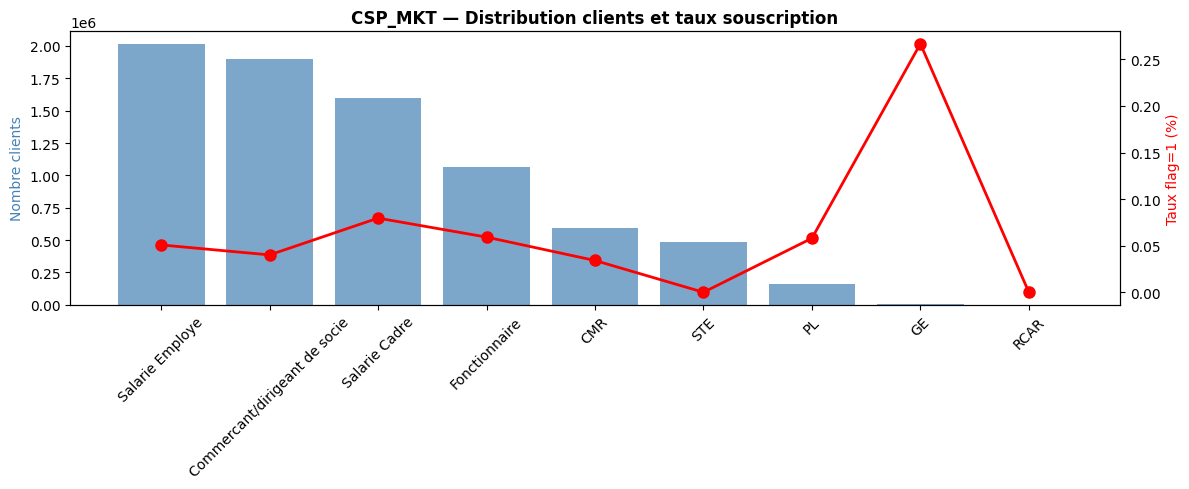

In [ ]:

import matplotlib.pyplot as plt


query = """
SELECT csp_mkt, COUNT(DISTINCT activite_profession) AS nb_professions,
       SUM(flag_transfo) AS nb_flag1,
       COUNT(*) AS total,
       ROUND(SUM(flag_transfo)*100.0/COUNT(*), 4) AS taux_flag1
FROM marts_marts.dataset_ml_v3
WHERE is_prediction_period = 0
AND csp_mkt IS NOT NULL
GROUP BY csp_mkt
ORDER BY total DESC;
"""
df = pd.read_sql(query, conn)
conn.close()

print(df.to_string(index=False))

# Graphique
fig, ax1 = plt.subplots(figsize=(12, 5))
bars = ax1.bar(df['csp_mkt'], df['total'], color='steelblue', alpha=0.7)
ax1.set_ylabel('Nombre clients', color='steelblue')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(df['csp_mkt'], df['taux_flag1'], 'ro-', linewidth=2, markersize=8)
ax2.set_ylabel('Taux flag=1 (%)', color='red')

plt.title('CSP_MKT — Distribution clients et taux souscription', fontweight='bold')
plt.tight_layout()
plt.savefig('../sql/resultats/14_csp_mkt_distribution.png', dpi=150)
plt.show()
